# HDFC Bank: Fraud Risk Analysis - Part 1

**Objective:** Exploratory Data Analysis (EDA) & Target Leakage Check

Now that we understand the schema, we analyze the business patterns of fraud and guarantee we aren't leaking future information into our models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))
from fraudguard.data.ingestion import load_bank_data

data_dir = Path.cwd().parent / "data" / "raw"
df = load_bank_data(data_dir)

## 1. Transaction Amount Analysis

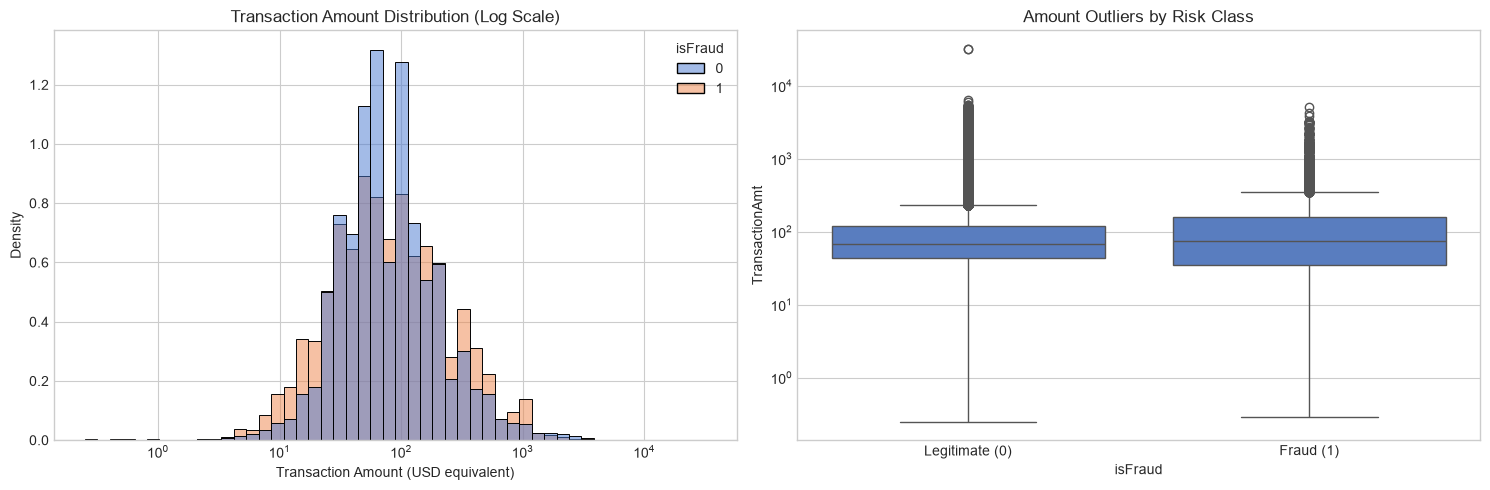

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=df, x='TransactionAmt', hue='isFraud', log_scale=True, 
             bins=50, ax=axes[0], common_norm=False, stat='density', alpha=0.5)
axes[0].set_title("Transaction Amount Distribution (Log Scale)")
axes[0].set_xlabel("Transaction Amount (USD equivalent)")

sns.boxplot(data=df, x='isFraud', y='TransactionAmt', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title("Amount Outliers by Risk Class")
axes[1].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
plt.tight_layout()
plt.show()

## 2. Card Network and Type Analysis

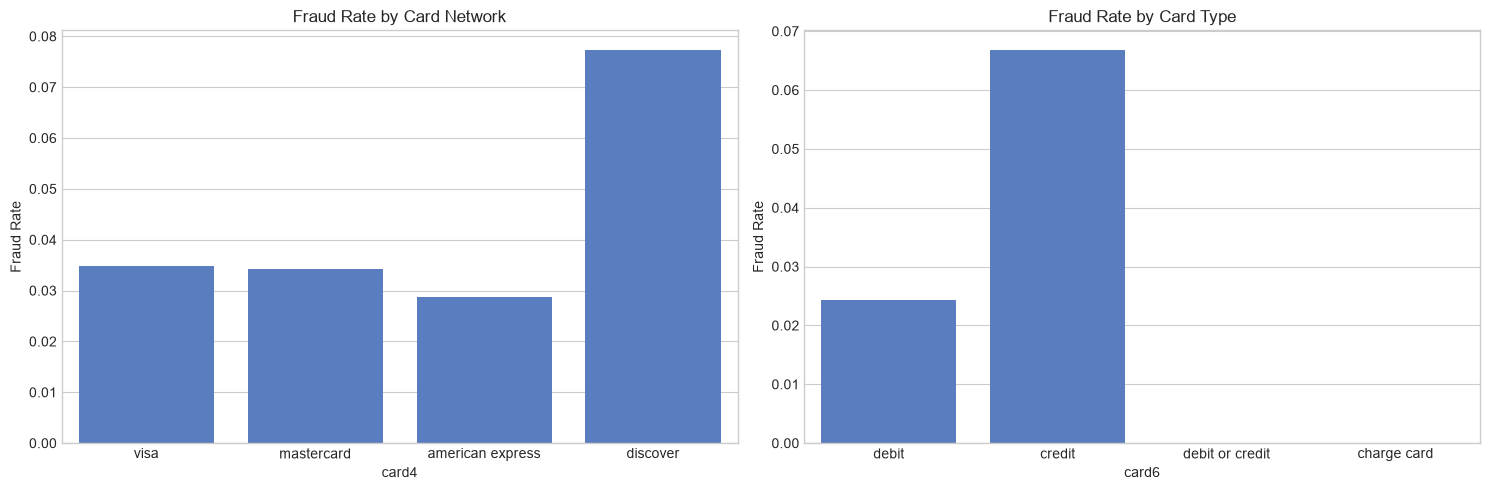

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
card_network_fraud = df.groupby('card4')['isFraud'].agg(['count', 'mean']).sort_values('count', ascending=False)
sns.barplot(x=card_network_fraud.index, y=card_network_fraud['mean'], ax=axes[0])
axes[0].set_title("Fraud Rate by Card Network")
axes[0].set_ylabel("Fraud Rate")

card_type_fraud = df.groupby('card6')['isFraud'].agg(['count', 'mean']).sort_values('count', ascending=False).head(4)
sns.barplot(x=card_type_fraud.index, y=card_type_fraud['mean'], ax=axes[1])
axes[1].set_title("Fraud Rate by Card Type")
axes[1].set_ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

## 3. Missing Identity Data as a Risk Signal

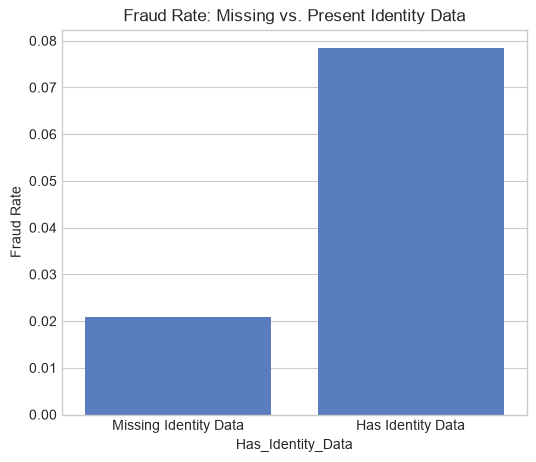

In [4]:
df['Has_Identity_Data'] = df['id_01'].notnull().astype(int)
id_fraud_rate = df.groupby('Has_Identity_Data')['isFraud'].agg(['count', 'mean'])

plt.figure(figsize=(6, 5))
sns.barplot(x=id_fraud_rate.index, y=id_fraud_rate['mean'])
plt.title("Fraud Rate: Missing vs. Present Identity Data")
plt.xticks([0, 1], ['Missing Identity Data', 'Has Identity Data'])
plt.ylabel("Fraud Rate")
plt.show()

## 4. Leakage Analysis (Pearson Correlation)

In [5]:
print("Running deep correlation analysis on numeric features...")
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['TransactionID', 'TransactionDT', 'isFraud', 'Has_Identity_Data'])
numeric_df = numeric_df.fillna(numeric_df.median())

correlations = numeric_df.corrwith(df['isFraud']).abs().sort_values(ascending=False)
print("\nTop 10 most correlated numeric features (Pearson):")
print(correlations.head(10))

if correlations.max() > 0.8:
    print("\nCRITICAL WARNING: Target leakage detected! Feature correlation > 0.8")
else:
    print("\nSYSTEM CHECK PASSED: No single numeric feature predicts fraud with > 80% correlation.")

Running deep correlation analysis on numeric features...

Top 10 most correlated numeric features (Pearson):
V257    0.280214
V246    0.268090
V244    0.265712
V242    0.263476
V201    0.246462
V200    0.238290
V45     0.235436
V189    0.225829
V86     0.222343
V87     0.221568
dtype: float64

SYSTEM CHECK PASSED: No single numeric feature predicts fraud with > 80% correlation.
